# Find alpha DSE1-4

May 4, 2025 - An attempt to reproduce the find alpha parameter using the DSE genes. The differences in the replicate fits and the shorter delta values make this procedure difficult to reliably reproduce consistently across both replicates. Replicate 1 produces very long alphas > 28, replicate 2 produces very short ones < 8. Whereas we would expect values between 12-20 proportionally to the length of the cell cycle as per Xin Guo's work.


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [98]:
from pipeline.CombinedDeconvolveGeneExpressionRunner \
    import CombinedDeconvolveGeneExpressionRunner

output_directory = 'output/prototype_pipeline_subset/'

runner = CombinedDeconvolveGeneExpressionRunner(output_directory, False)


In [99]:
from src.config import load_cloccs_configs
config1, config2 = load_cloccs_configs()

In [1547]:
def gene_alpha_search(gene_name, kappa, replicate, alphas=None):

    solutions = []
    print(f"Searching replicate {replicate } alphas: {gene_name}...")

    for alpha in alphas:
        print(alpha, end=",")
        if replicate == 1:
            runner.config1.modify_alpha(alpha)
        elif replicate == 2:
            runner.config2.modify_alpha(alpha)
        find_gamma = runner.deconvolve_gene_find_gamma(gene_name, kappa=kappa,
            replicate=replicate)   
    
        solution = find_gamma.retrieve_solution()
        solutions.append(solution)
    print()

    df = pd.DataFrame(solutions, index=alphas)
    df.index.name = 'alpha'
    df['gene'] = gene_name
    df['replicate'] = replicate
    df = df.reset_index().set_index(['replicate', 'alpha', 'gene'])
    
    return df


In [1588]:
from src.timer import Timer
timer = Timer()
alphas = np.arange(4, 49, 4)
print("Number of alphas: ", len(alphas))

gene_names = ['DSE1', 'DSE2', 'DSE3', 'DSE4',
    'ASH1', 'EGT2', 'AMN1', 'PRY3', 'SCW11', 'CTS1']

solutions = []
for replicate in [1, 2]:
    for gene_name in gene_names:
        solution_result = gene_alpha_search(gene_name, kappa=0.0, 
                                          replicate=replicate, alphas=alphas)
        solutions.append(solution_result)
        timer.print_time()

all_alpha_results_df = pd.concat(solutions)

Number of alphas:  12
Searching replicate 1 alphas: DSE1...
4,8,12,16,20,24,28,32,36,40,44,48,
00:00:49.418
Searching replicate 1 alphas: DSE2...
4,8,12,16,20,24,28,32,36,40,44,48,
00:01:37.077
Searching replicate 1 alphas: DSE3...
4,8,12,16,20,24,28,32,36,40,44,48,
00:02:25.367
Searching replicate 1 alphas: DSE4...
4,8,12,16,20,24,28,32,36,40,44,48,
00:03:17.863
Searching replicate 1 alphas: ASH1...
4,8,12,16,20,24,28,32,36,40,44,48,
00:04:06.569
Searching replicate 1 alphas: EGT2...
4,8,12,16,20,24,28,32,36,40,44,48,
00:04:55.292
Searching replicate 1 alphas: AMN1...
4,8,12,16,20,24,28,32,36,40,44,48,
00:05:42.611
Searching replicate 1 alphas: PRY3...
4,8,12,16,20,24,28,32,36,40,44,48,
00:06:30.224
Searching replicate 1 alphas: SCW11...
4,8,12,16,20,24,28,32,36,40,44,48,
00:07:16.106
Searching replicate 1 alphas: CTS1...
4,8,12,16,20,24,28,32,36,40,44,48,
00:08:02.417
Searching replicate 2 alphas: DSE1...
4,8,12,16,20,24,28,32,36,40,44,48,
00:08:48.504
Searching replicate 2 alphas: D

In [1589]:
from src.alpha_search import plot_alpha_genes_subplots

In [1590]:
from src.utils import mkdir_safe
from src.figure_configs import save_figure_for_paper
save_dir = f"{output_directory}/alpha_search"

mkdir_safe(save_dir)

Creating directory: output/prototype_pipeline_subset//alpha_search...Directory exists. Skipping.


Saved figure to: output/prototype_pipeline_subset//alpha_search/alphas_repl1.png


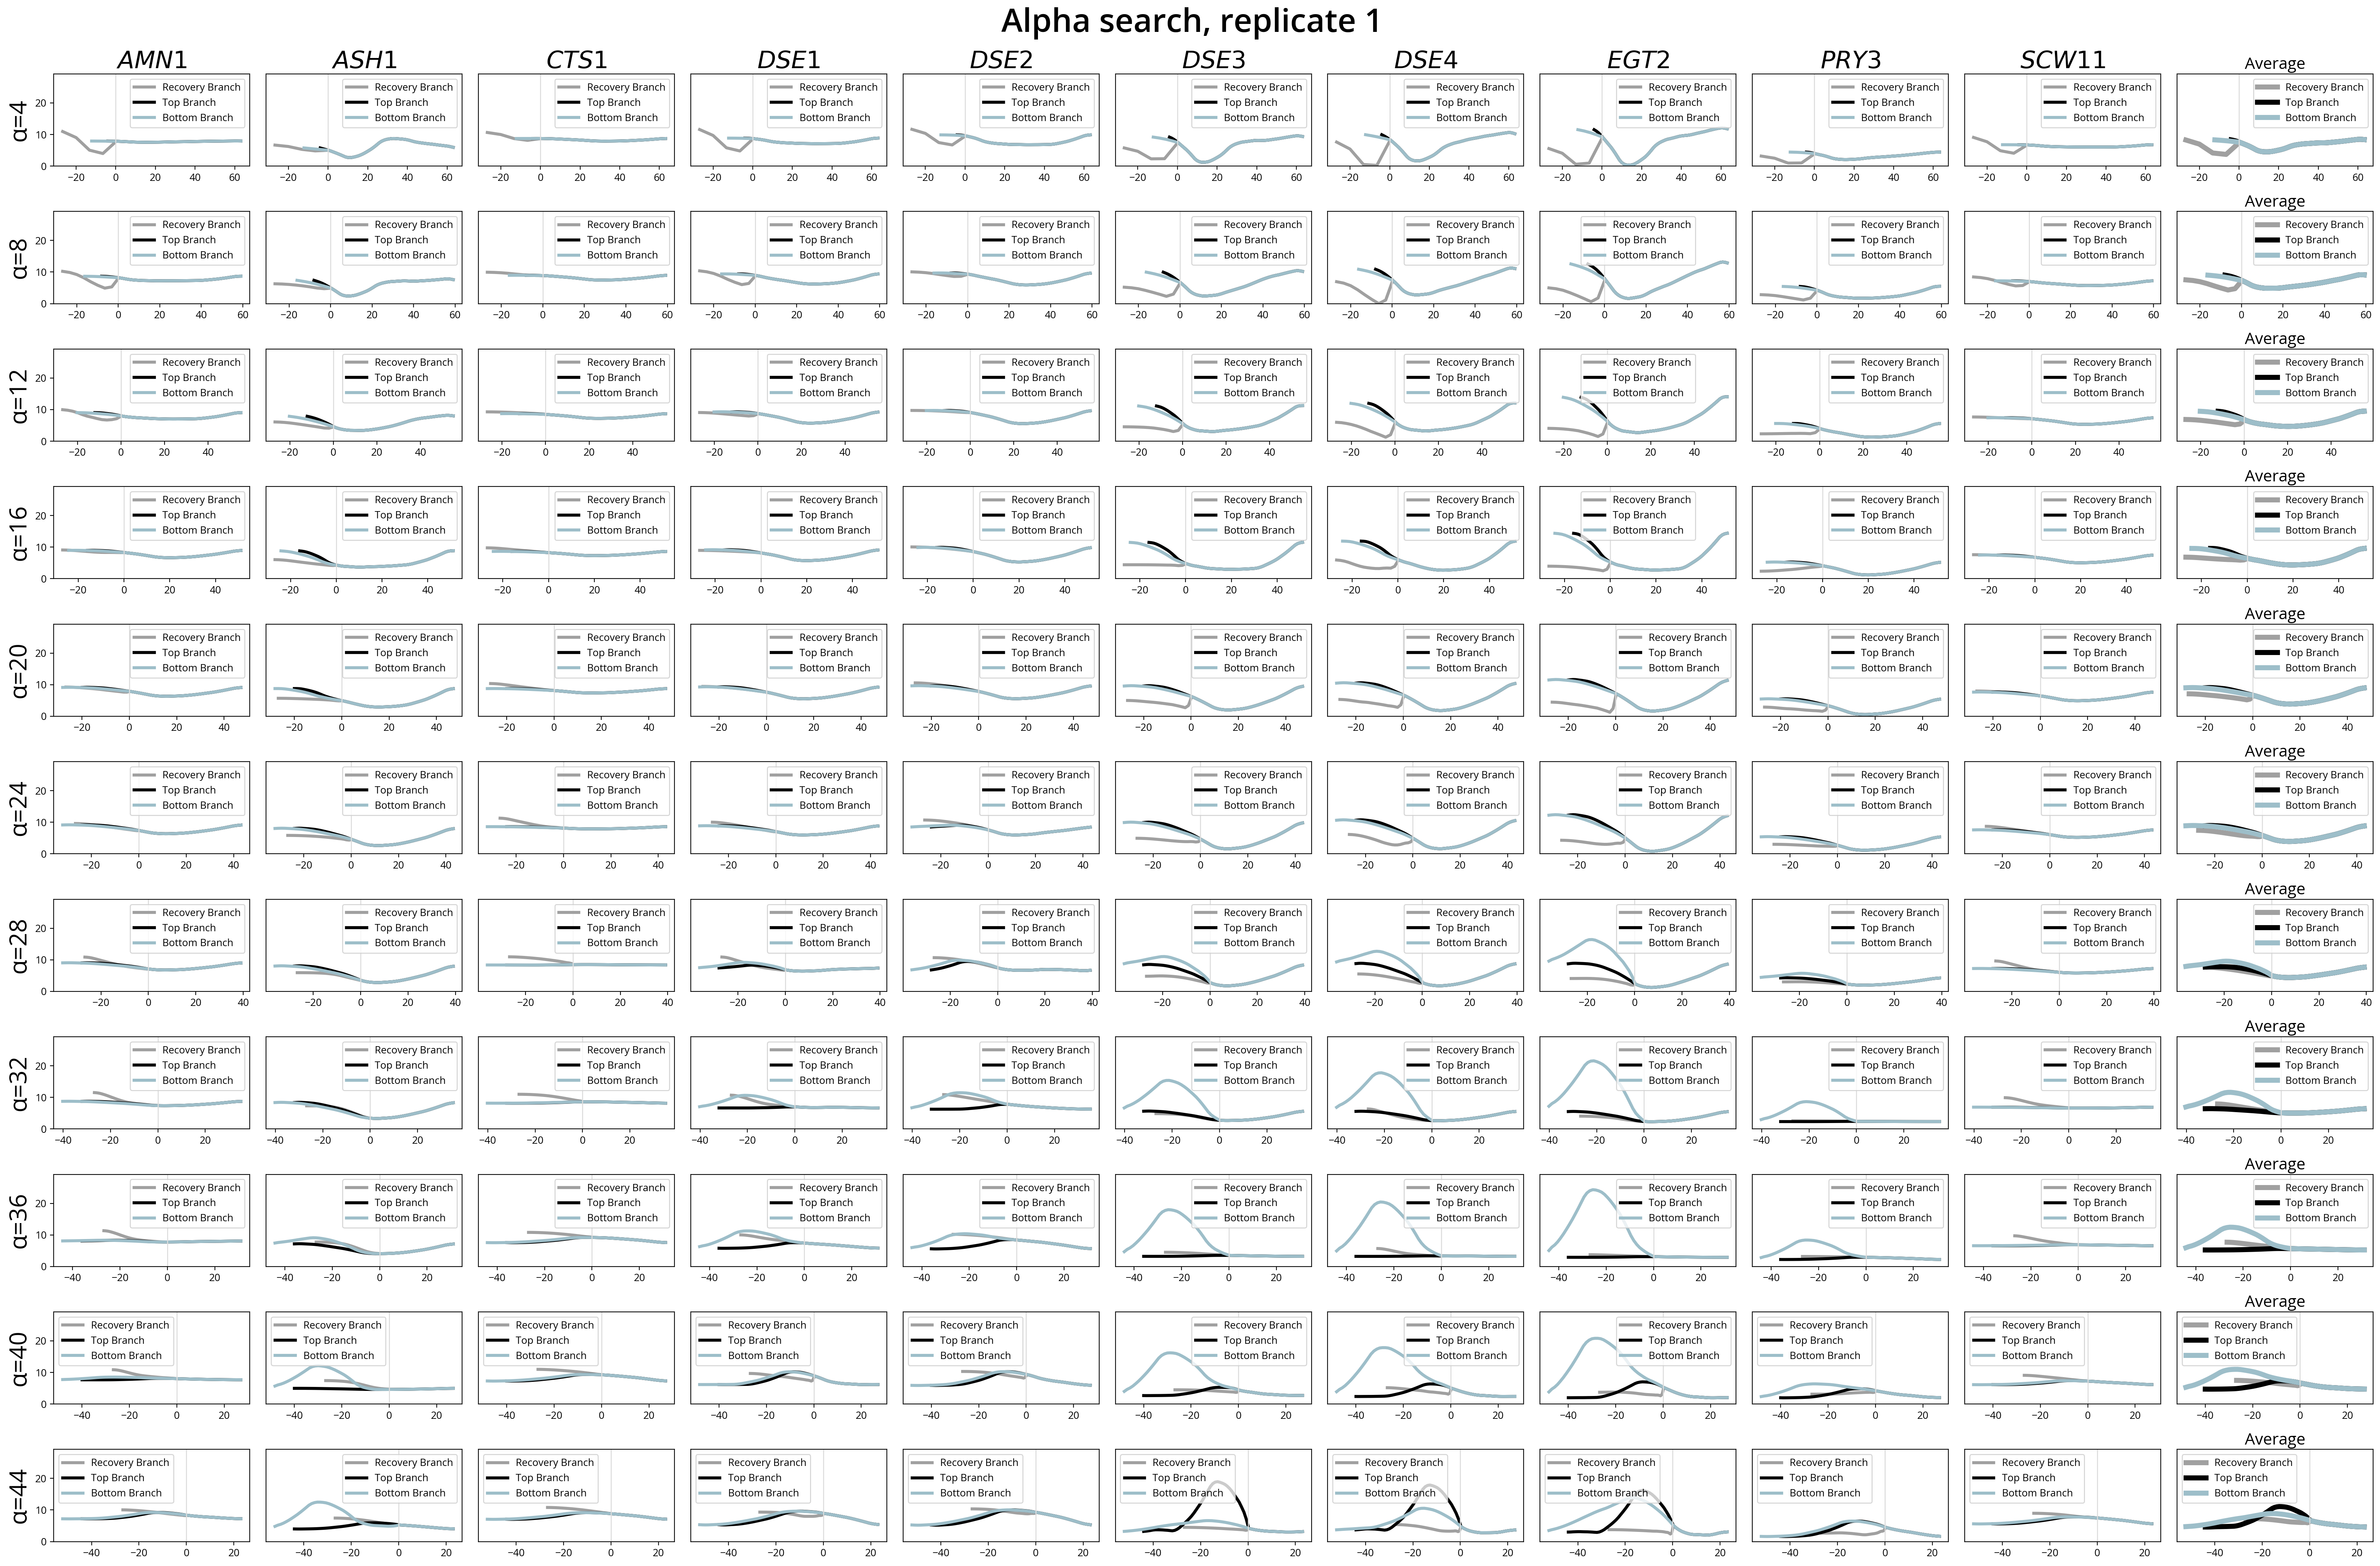

In [1591]:
plot_alphas = np.arange(4, 48, 4)
fig = plot_alpha_genes_subplots(config1, plot_alphas, all_alpha_results_df, 1)

all_alpha_results_df.to_csv(f"{save_dir}/alphas_repl1.csv")
save_figure_for_paper(f"{save_dir}/alphas_repl1.png", dpi=80)


Saved figure to: output/prototype_pipeline_subset//alpha_search/alphas_repl2.png


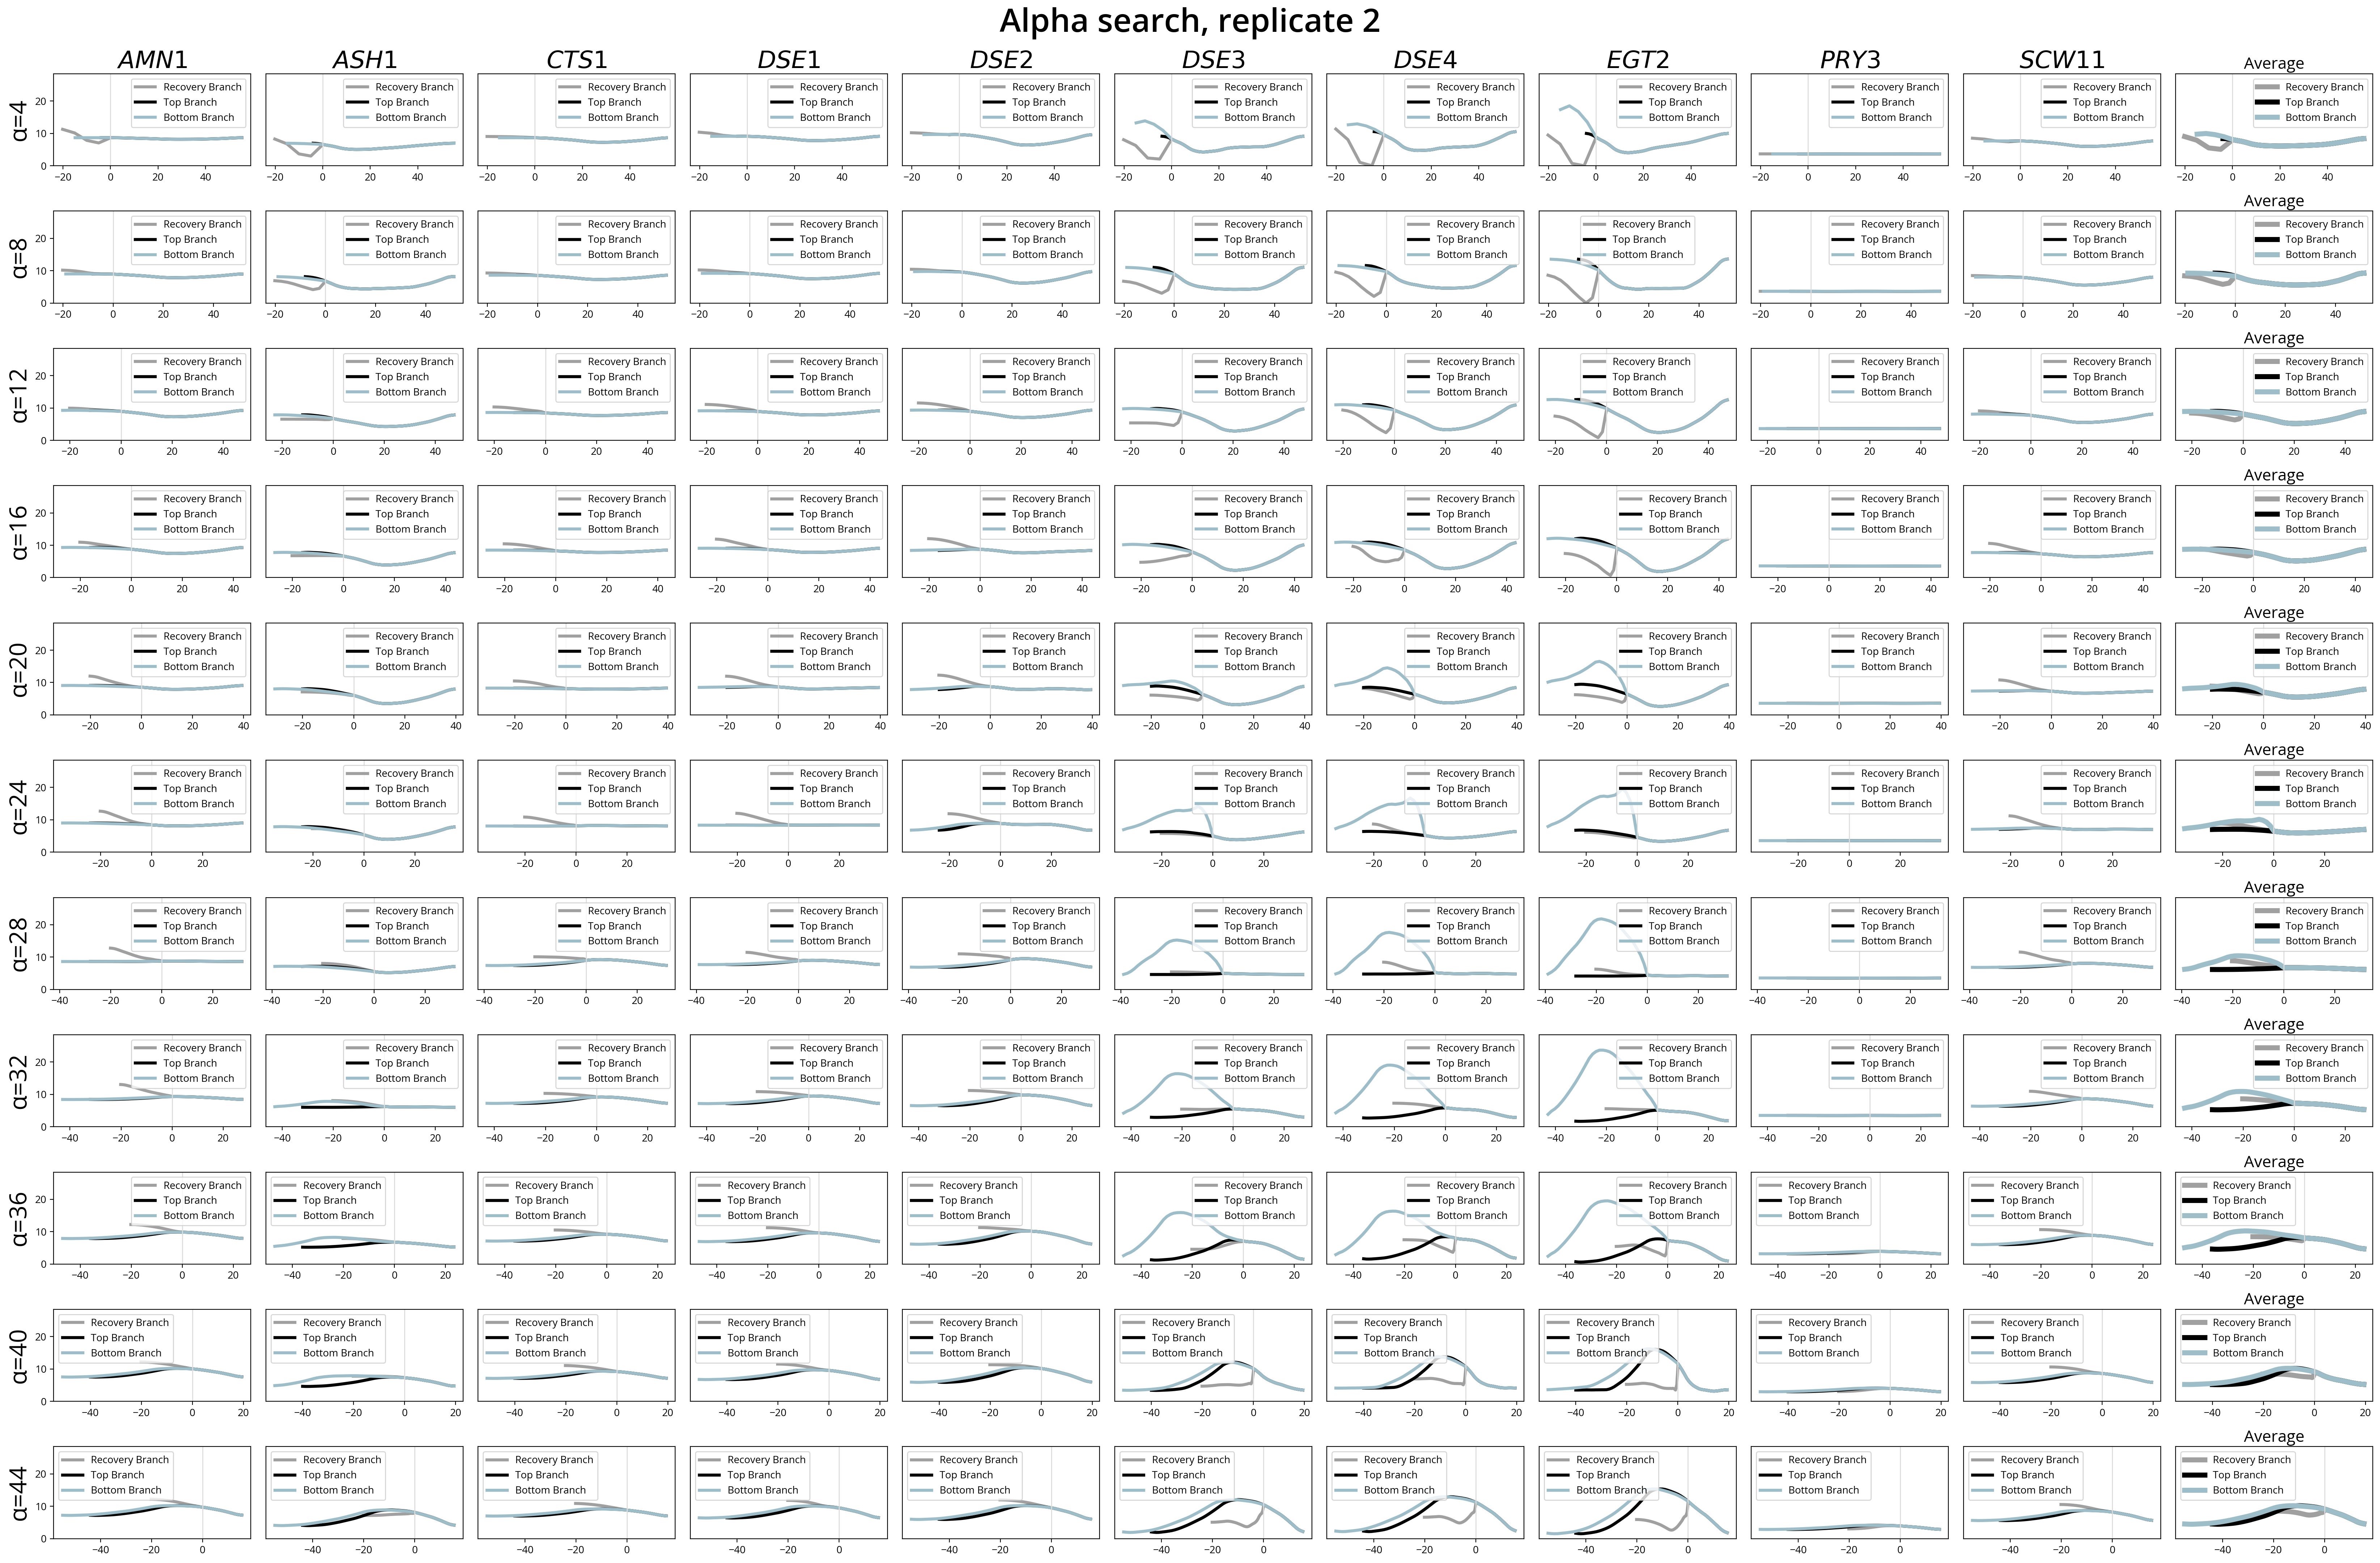

In [1592]:
fig = plot_alpha_genes_subplots(config2, plot_alphas, all_alpha_results_df, 2)

all_alpha_results_df.to_csv(f"{save_dir}/alphas_repl2.csv")
save_figure_for_paper(f"{save_dir}/alphas_repl2.png", dpi=80)

In [259]:
runner.config1.modify_alpha(30)

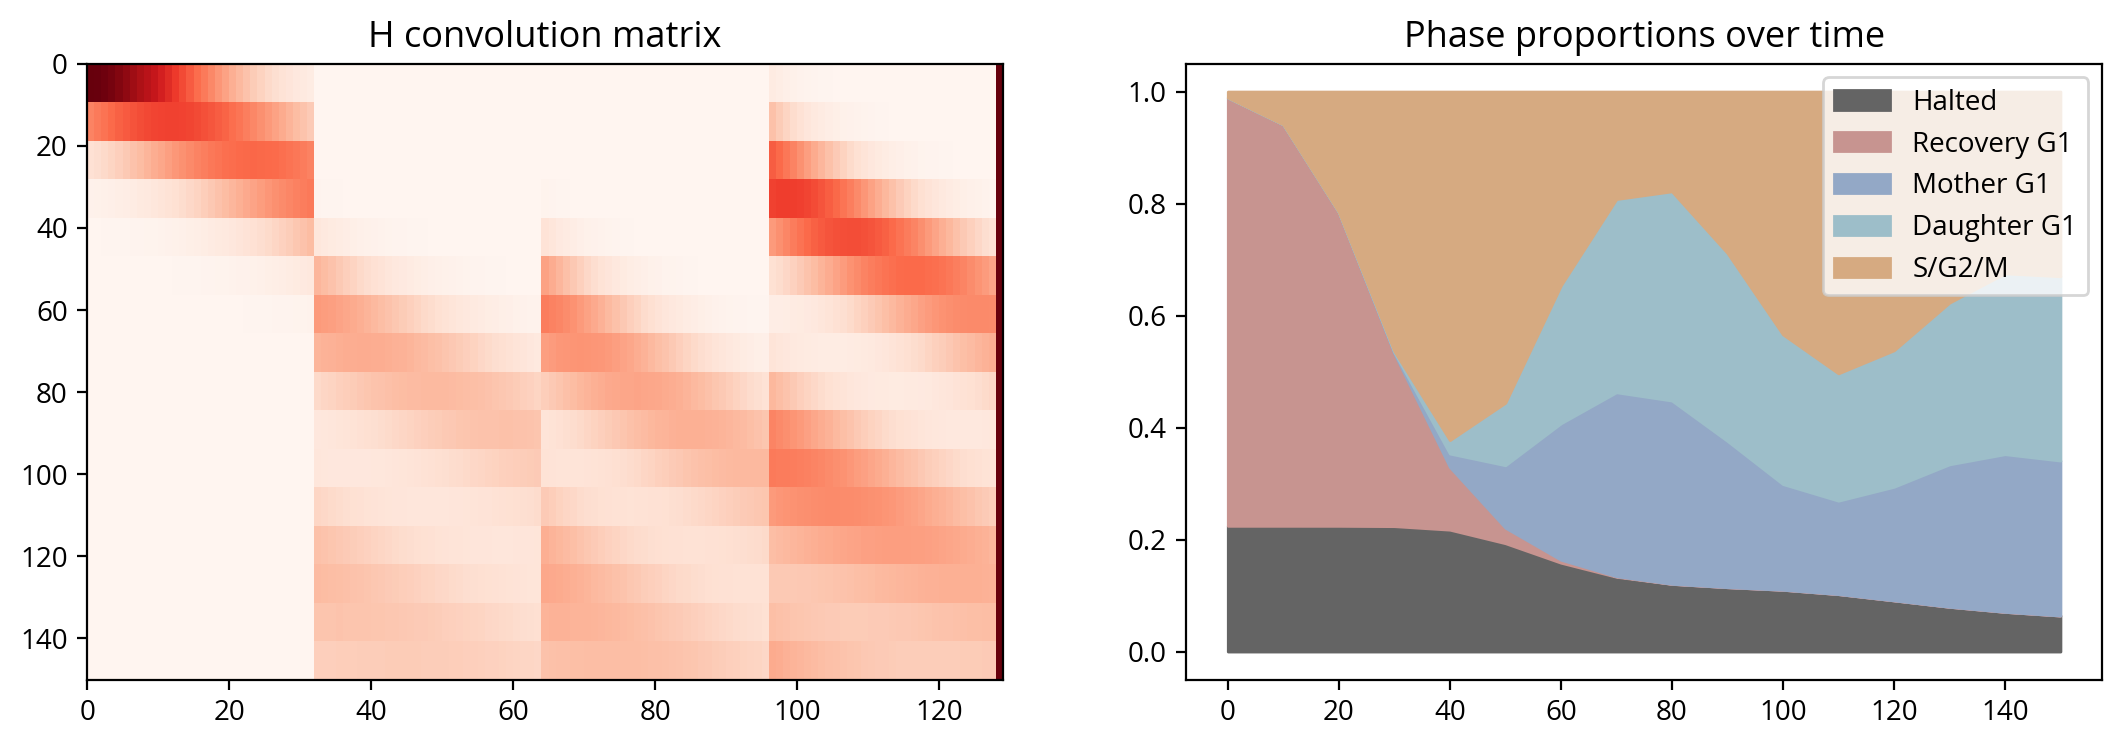

In [264]:
runner.config1.plot_H()

In [1706]:
runner.deconvolve_gene_find_gamma('DSE1', replicate=1)

In [1707]:
runner.expression_find_gamma.gamma_optimizer.gamma_left,\
runner.expression_find_gamma.gamma_optimizer.gamma_right

(0.00010038108825683595, 0.0999996189131969)

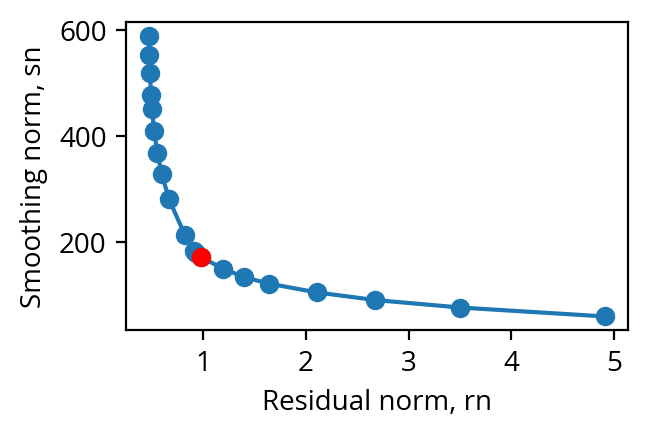

In [1708]:
runner.expression_find_gamma.gamma_optimizer.plot_elbow()

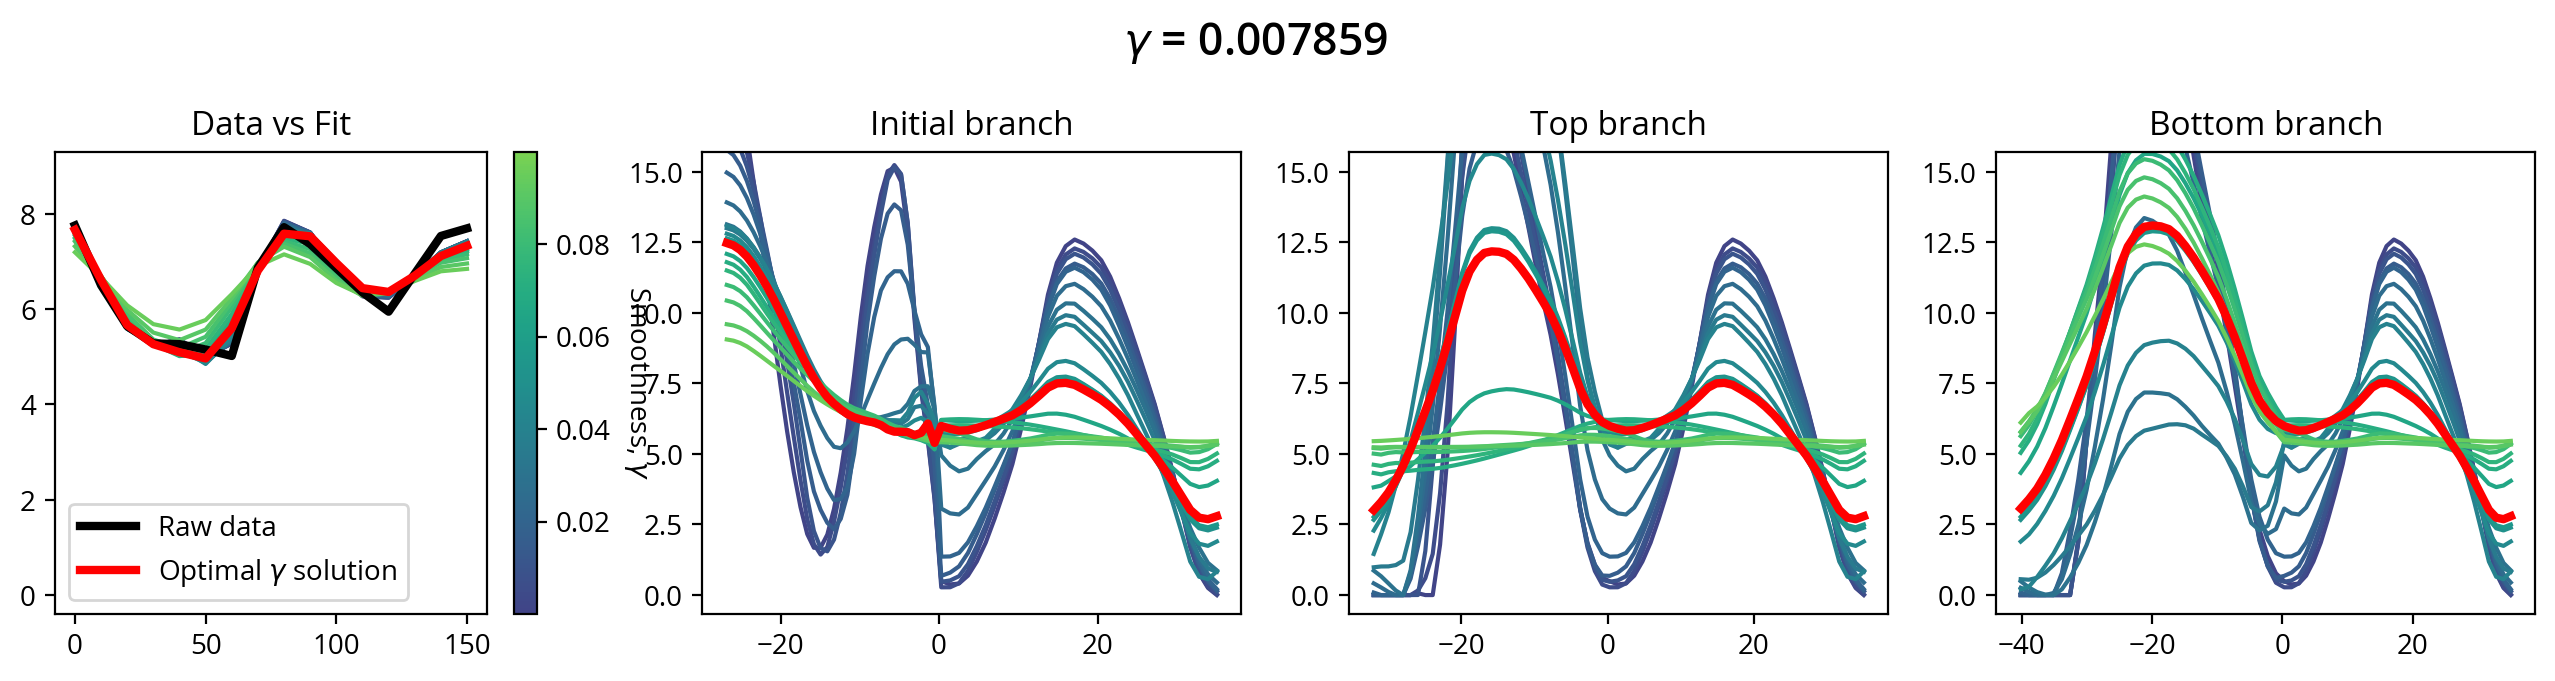

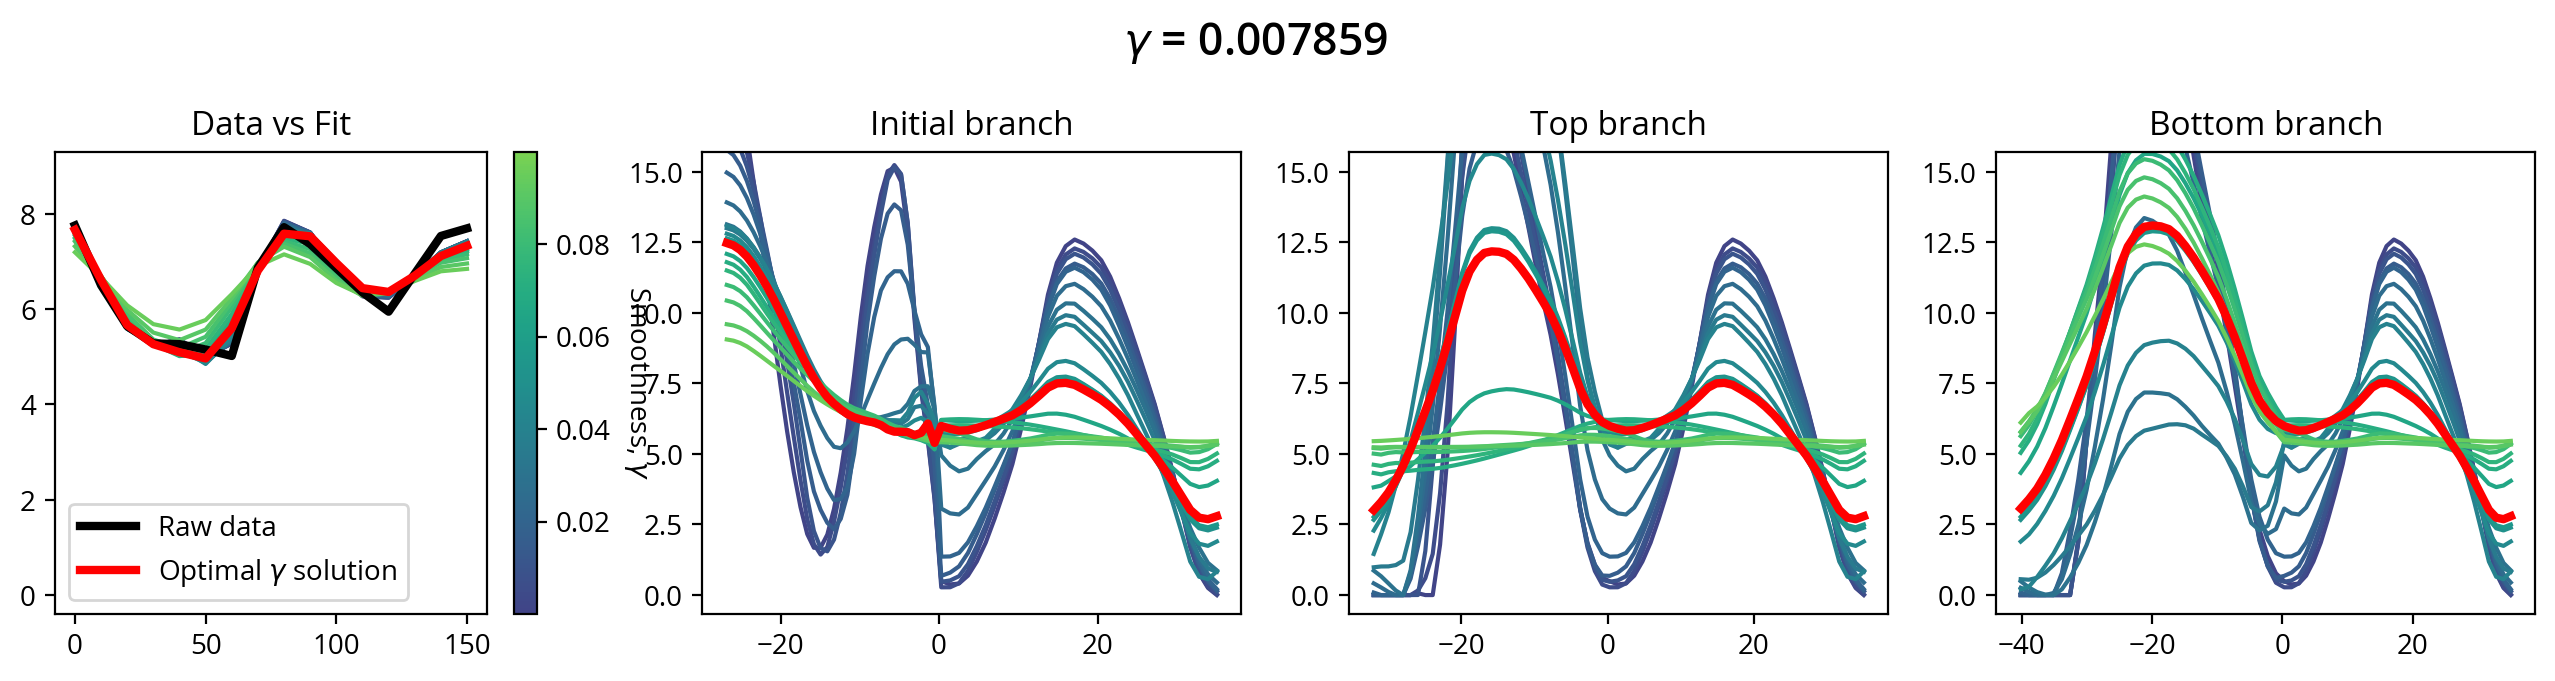

In [1709]:
runner.expression_find_gamma.plot_gamma_sweep()

In [1710]:
runner.expression_find_gamma.deconvolution_solver.gamma = 0.01
runner.expression_find_gamma.deconvolution_solver.deconvolve()

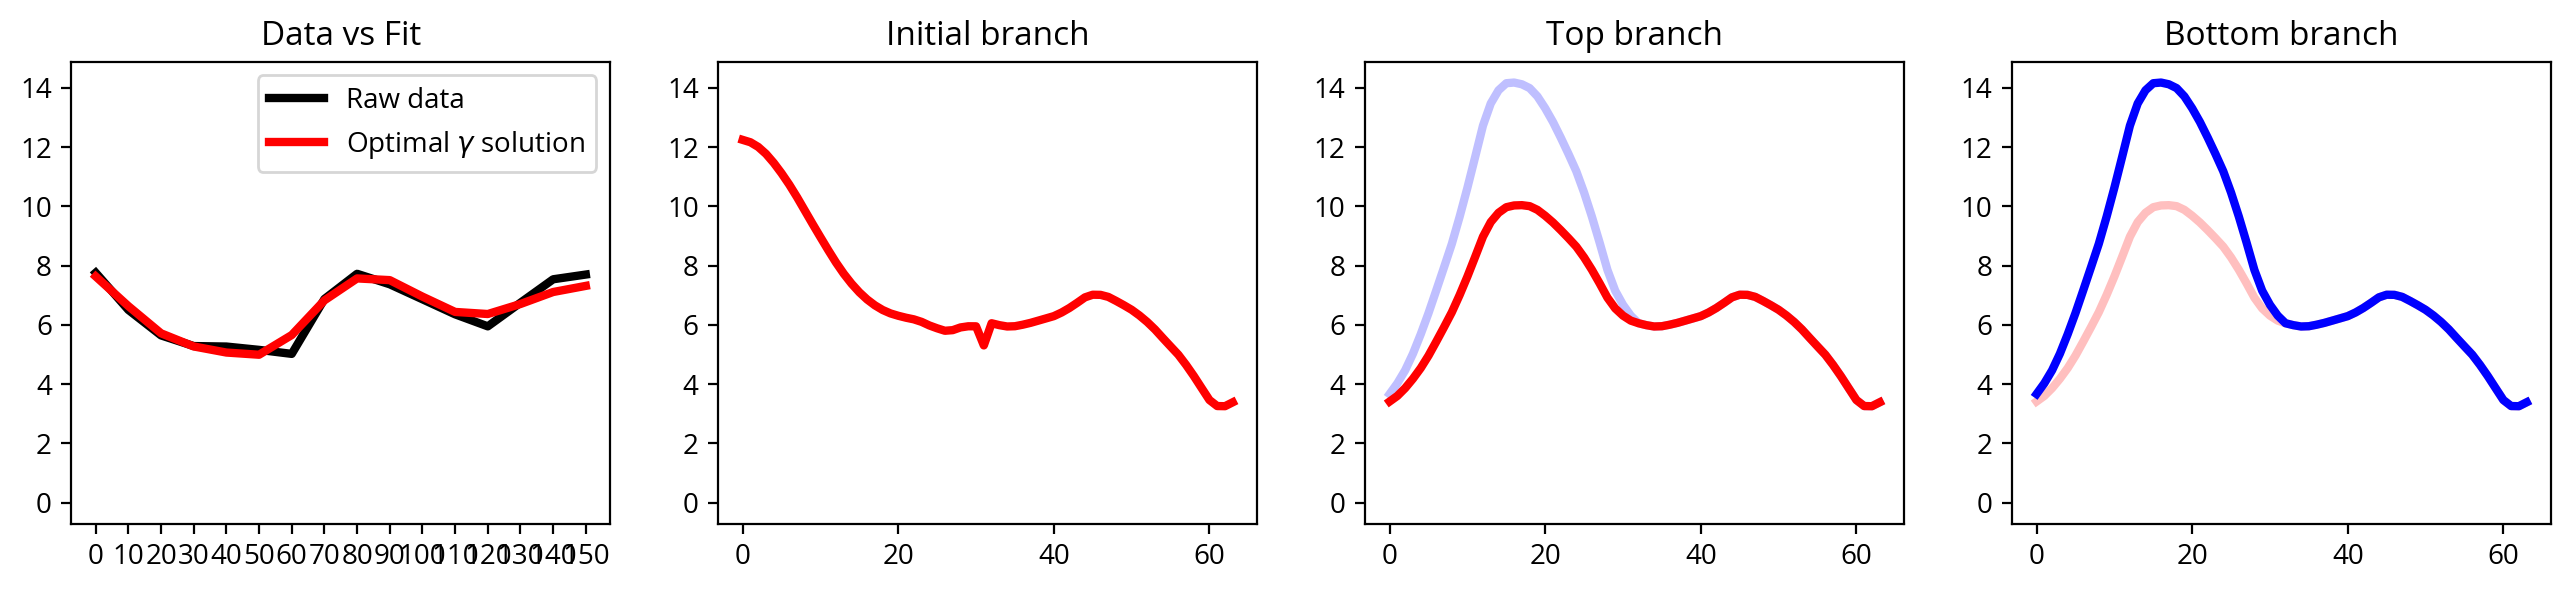

In [1711]:
runner.expression_find_gamma.deconvolution_solver.plot_fit()